In [41]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import joblib

In [42]:
import sys
print(sys.executable)

d:\space 2.0\.idlerc\Predictive-Maintenance-ML\.venv\Scripts\python.exe


In [43]:
#Load dataset
data=pd.read_csv("../dataset/ai4i2020.csv")

In [44]:
data.head()
data.columns
data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [45]:
data.shape

(10000, 14)

In [46]:
data.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [48]:
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [49]:
data['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

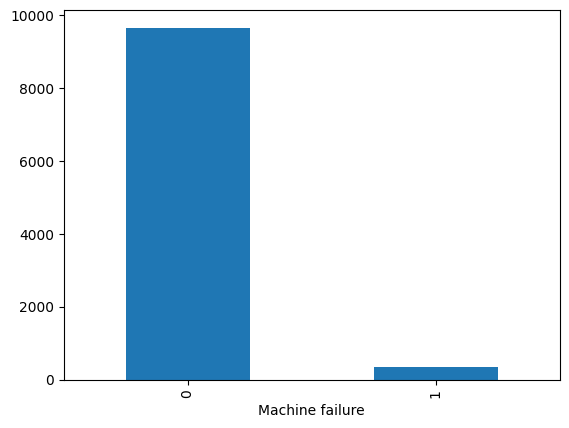

In [50]:
data["Machine failure"].value_counts().plot(kind="bar")
plt.show()

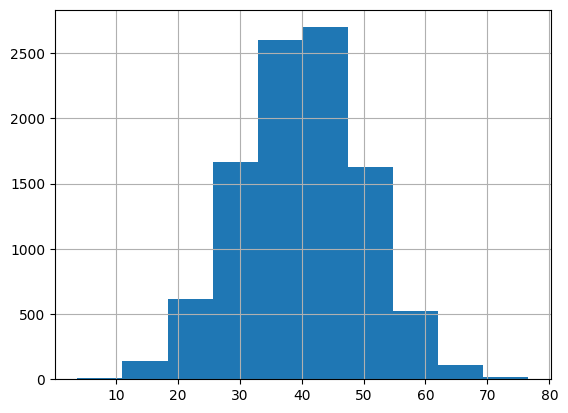

In [51]:
data["Torque [Nm]"].hist()
plt.show()

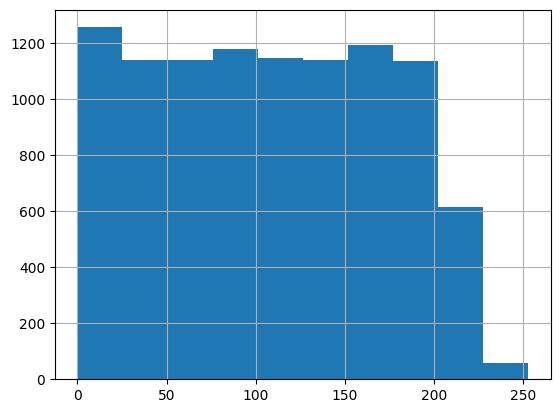

In [52]:
data["Tool wear [min]"].hist()
plt.show()

In [53]:
data.groupby("Machine failure")[["Torque [Nm]", "Tool wear [min]", "Process temperature [K]"]].mean()

,Torque [Nm],Tool wear [min],Process temperature [K]
Machine failure,,,
0,39.629655,106.693717,309.995570
1,50.168142,143.781711,310.290265


In [54]:
import sklearn
print(sklearn.__version__)

1.8.0


In [55]:
#Train test split
from sklearn.model_selection import train_test_split

In [56]:
data_clean=data.drop(columns=['UDI',
        'Product ID','Type',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'])
data_clean.columns
X = data_clean.drop(columns=['Machine failure'])

y = data_clean['Machine failure']
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB


In [57]:
X.head
X.info

<bound method DataFrame.info of       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                   298.1                    308.6                    1551   
1                   298.2                    308.7                    1408   
2                   298.1                    308.5                    1498   
3                   298.2                    308.6                    1433   
4                   298.2                    308.7                    1408   
...                   ...                      ...                     ...   
9995                298.8                    308.4                    1604   
9996                298.9                    308.4                    1632   
9997                299.0                    308.6                    1645   
9998                299.0                    308.7                    1408   
9999                299.0                    308.7                    1500   

      Torque [Nm]  Tool wear [m

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [59]:
#Logistic regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
predictions=model.predict(X_test)

In [61]:
print(predictions[:5])

[0 0 0 0 0]


In [62]:
#logistic regression-accuracy
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print(accuracy)

0.9725


In [63]:
predictionss=model.predict(X_train)
accuracyy=accuracy_score(y_train,predictionss)
print(accuracyy)

0.969375


In [64]:
data['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [65]:
#logistic regression-confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predictions)
print(cm)

[[1929   10]
 [  45   16]]


In [66]:
#decissiontree
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
import pandas as pd

data=pd.read_csv("../dataset/ai4i2020.csv")
data_clean=data.drop(columns=['UDI',
        'Product ID','Type',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'])
data_clean.columns
X = data_clean.drop(columns=['Machine failure'])

y = data_clean['Machine failure']
data_clean.info()
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)
model.fit(X_train,y_train)
predictions=model.predict(X_test)
print(predictions)
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print(accuracy)

predictionss=model.predict(X_train)
print(predictionss)
accuracyy=accuracy_score(y_train,predictionss)
print(accuracyy)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air temperature [K]      10000 non-null  float64
 1   Process temperature [K]  10000 non-null  float64
 2   Rotational speed [rpm]   10000 non-null  int64  
 3   Torque [Nm]              10000 non-null  float64
 4   Tool wear [min]          10000 non-null  int64  
 5   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 468.9 KB
[0 0 0 ... 0 1 0]
0.9795
[0 0 0 ... 0 0 0]
1.0


In [67]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predictions)
print(cm)

[[1916   23]
 [  18   43]]


In [68]:
#random forest
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
predictions=model.predict(X_test)
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy=accuracy_score(y_test,predictions)
print(accuracy)
cm=confusion_matrix(y_test,predictions)
print(cm)

0.9835
[[1931    8]
 [  25   36]]


In [69]:
#feature importance
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, score)

Air temperature [K] 0.16156544874046663
Process temperature [K] 0.1488310593176357
Rotational speed [rpm] 0.2147124702638528
Torque [Nm] 0.3209545766838526
Tool wear [min] 0.15393644499419223


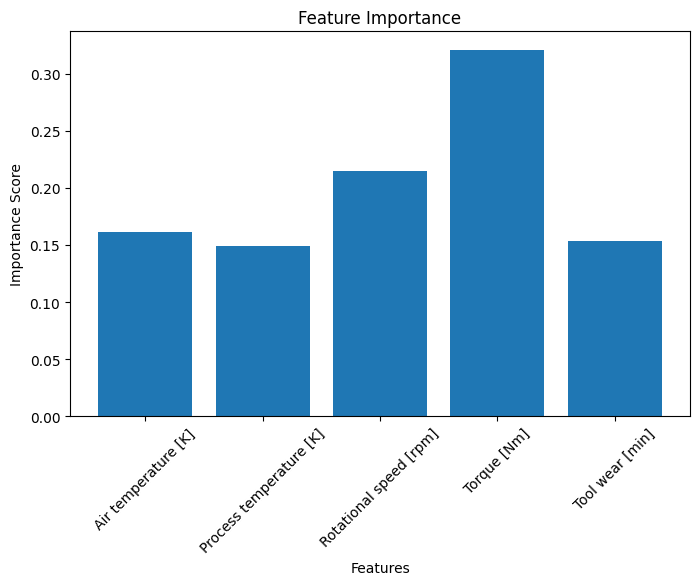

In [70]:
import matplotlib.pyplot as plt
importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

In [71]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                   Feature  Importance
3              Torque [Nm]    0.320955
2   Rotational speed [rpm]    0.214712
0      Air temperature [K]    0.161565
4          Tool wear [min]    0.153936
1  Process temperature [K]    0.148831


In [72]:
#save and load model
import joblib

joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [73]:
loaded_model = joblib.load("random_forest_model.pkl")

In [74]:
loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])

In [75]:
import os

print(os.path.exists("random_forest_model.pkl"))

True


In [76]:
#Sample prediction
air_temp = 300
process_temp = 310
rpm = 1500
torque = 50
tool_wear = 120
sample = [[
    air_temp,
    process_temp,
    rpm,
    torque,
    tool_wear
]]
prediction = loaded_model.predict(sample)

if prediction[0] == 1:
    print(" Machine Failure Predicted")
else:
    print(" Machine Healthy")

 Machine Healthy


d:\space 2.0\.idlerc\Predictive-Maintenance-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [77]:
import os
print(os.getcwd())

d:\space 2.0\.idlerc\Predictive-Maintenance-ML\notebooks


In [78]:
import os

print(os.listdir())

['main.ipynb', 'random_forest_model.pkl']


# Conclusion

- The dataset contained 10,000 machine records.
- Machine failures represented only 3.39% of the data.
- Random Forest achieved the highest accuracy (98.35%).
- Decision Tree detected the highest number of failure cases.
- Torque was identified as the most important feature for predicting failures.
- Machine learning can be used to predict potential machine failures using sensor data.